In [56]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pytensor as pt

df = pd.read_csv('data.csv', keep_default_na=False, na_values=[''])
df

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,closedByRegion_2024,totalByState_2025,closedByState_2025,totalByRegion_2025,closedByRegion_2025,regionUnemploymentRate,totalByStateMean,totalByRegionMean,closedByStateMean,closedByRegionMean
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,4,67,0,2045,2,3.6,68.50,2052.50,0.50,1.50
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,8,406,0,1146,0,4.1,412.50,1160.25,1.00,2.25
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,9,100,0,1301,4,4.1,101.50,1318.25,0.25,3.25
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,8,141,0,1146,0,4.1,142.75,1160.25,0.50,2.25
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,8,143,0,1146,0,4.1,144.00,1160.25,0.25,2.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Eastern Nazarene College,1900,Massachusetts,MA,Suburb,Large,Private,Nonprofit,4-year,True,...,8,141,0,1146,0,4.1,142.75,1160.25,0.50,2.25
61,Cox College,1907,Missouri,MO,City,Midsize,Private,Nonprofit,4-year,True,...,9,136,2,1301,4,4.1,136.25,1318.25,0.25,3.25
62,University of Wisconsin–Platteville Richland,1967,Wisconsin,WI,Town,Distant,Public,Nonprofit,4-year,True,...,9,82,1,1301,4,4.1,87.25,1318.25,0.50,3.25
63,Maryland University of Integrative Health,1974,Maryland,MD,Suburb,Large,Private,Nonprofit,graduate school,False,...,4,77,1,2045,2,3.6,77.00,2052.50,0.00,1.50


In [57]:
n_s = df.groupby('state')['totalByState_2020'].mean().round(0).astype(int)
y_s = df['state'].value_counts()

all_states = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_states)
y_s = y_s.reindex(all_states)

# variable inflation factor (VIF)
# no frequent approach

a = 1 # 55
b = 100 # 4000
# (2,2) will put center of the prior at 0.5

a_post = a + y_s
b_post = b + n_s - y_s

post_means = a_post / (a_post + b_post)
post_vars = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post,
    'b_post': b_post,
    'post_mean': post_means,
    'post_var': post_vars
})
print(results)

               n_s  y_s  a_post  b_post  post_mean  post_var
Alabama         78    2       3     176   0.016760  0.000092
California     658    6       7     752   0.009223  0.000012
Delaware        16    1       2     115   0.017094  0.000142
Florida        320    2       3     418   0.007126  0.000017
Illinois       235    5       6     330   0.017857  0.000052
Indiana        102    2       3     200   0.014778  0.000071
Iowa            75    1       2     174   0.011364  0.000063
Maryland        77    1       2     176   0.011236  0.000062
Massachusetts  144    3       4     241   0.016327  0.000065
Michigan       154    2       3     252   0.011765  0.000045
Missouri       136    3       4     233   0.016878  0.000070
Nebraska        40    1       2     139   0.014184  0.000098
Nevada          35    1       2     134   0.014706  0.000106
New Hampshire   34    1       2     133   0.014815  0.000107
New Jersey     144    1       2     243   0.008163  0.000033
New York       413    7 

**1. What kind of distribution should $ x $ come from, and how should this be set up?**

The random variable $ x_s $ should come from a Normal distribution, $ x_s \sim N(\mu, \sigma^2) $. To ensure $ \alpha_s, \beta_s > 0 $, we set $ \alpha_s = \exp(x_s) $, $ \beta_s = \exp(k \cdot x_s) $, where $ k > 0 $ is a fixed scaler (e.g., $ k=1 $ for now) or estimated. We should use uninformative hyperpriors $ \mu \sim N(0, 100) $, $ \sigma \sim \Gamma(0.01, 0.01)$. Alternatively, a Gamma distribution $ x_s \sim \Gamma(0.01, 0.01) $ could be used too since its naturally positive.

**2. Mapping from the rat tumor example**

Rat Tumor Example: Models tumor rates across experiments, with $ y_j \sim \text{Binomial}(n_j, \theta_j) $, $ \theta_j \sim \text{Beta}(\alpha, \beta) $, and hyperpriors on $ \alpha, \beta $ or $ \text{logit}(\theta_j) \sim N(\mu, \sigma^2) $, allowing information sharing across experiments.
Mapping to College Closures:

Experiments $ \to $ States: Each state $ s $ has $ n_s $ colleges (trials) and $ y_s $ closures (successes).

Tumor rate $ \theta_j \to $ Closure probability $ p_s $: $ p_s \sim \text{Beta}(\alpha_s, \beta_s) $.

Random variable: Variation in $ \theta_j $ maps to $ x_s $, with $ \alpha_s = \exp(x_s) $, $ \beta_s = \exp(k \cdot x_s) $.

Hyperpriors: $ x_s \sim N(\mu, \sigma^2) $, $ \mu \sim N(0, 100) $, $ \sigma \sim \Gamma(0.01, 0.01)$.

Overall, we get a hierarchical Beta-Binomial model with $ y_s \sim \text{Binomial}(n_s, p_s) $, $ p_s \sim \text{Beta}(\exp(x_s), \exp(k \cdot x_s)) $, $ x_s \sim N(\mu, \sigma^2) $, computed via a Monte Carlo simulation.

**3. Does the hyperprior and posterior for the hidden parameter match your previous answer? How are we interpreting college closures with this setup?**

Hyperprior/Posterior Consistency: The hyperprior $ x_s \sim N(\mu, \sigma^2) $ aligns with the rat tumor example’s structure (e.g., Normal prior on $ \text{logit}(\theta_j) $). The posterior for $ x_s $, $ \mu $, and $ \sigma $ is not analytically tractable due to non-conjugacy from the exponential transformation and so requires MCMC for computation, hence the Normal hyperprior.

Interpretation: College closures are modeled as Binomial outcomes (closed, open) with state-specific probabilities $ p_s \sim \text{Beta}(\exp(x_s), \exp(k \cdot x_s)) $, where $ x_s \sim N(\mu, \sigma^2) $ represents random state-specific factors. The hierarchical structure assumes states share a common process, with $ x_s $ capturing variations. Posterior estimates of $ p_s $ are shrunk toward a common mean, improving accuracy for states with sparse data.

In [ ]:
# n_s = df.groupby('state')['totalByState_2025'].mean().round(0).astype(int)
# y_s = df['state'].value_counts()

# all_states = pd.Index(list(n_s.index) + list(y_s.index)).unique()
# n_s = n_s.reindex(all_states)
# y_s = y_s.reindex(all_states)

# with pt.config.change_flags(exception_verbosity='high'):
#     with pm.Model() as model:
#         # mu ~ N(0, 100)
#         mu = pm.Normal('mu', mu=0, sigma=10)
#         ## sigma ~ Gamma(0.01, 0.01)
#         # sigma = pm.Gamma('sigma', alpha=0.01, beta=0.01)
#         # alt: InverseGamma(0.01, 0.01) for sigma (AI)
#         sigma = pm.InverseGamma('sigma', alpha=0.01, beta=0.01)

#         ## x_s ~ N(mu, sigma)
#         # x_s = pm.Normal('x_s', mu=mu, sigma=sigma, shape=len(n_s))
#         ## alt: raw variable then transform 
#         x_s_raw = pm.Normal('x_s_raw', mu=0, sigma=1, shape=len(n_s))
#         x_s = pm.Deterministic('x_s', mu + sigma * x_s_raw)

#         # a_s ~ exp(x_s)
#         a_s = pm.Deterministic('alpha_s', pm.math.exp(x_s))
#         # b_s ~ exp(x_s * k)
#         k = 1 # for now
#         b_s = pm.Deterministic('beta_s', pm.math.exp(x_s * k))

#         # p_s ~ Beta(a_s, b_s)
#         p_s = pm.Beta('p_s', alpha=a_s, beta=b_s, shape=len(n_s))

#         # likelihood ~ Binomial(n_s, p_s)
#         y = pm.Binomial('y', n=n_s.values, p=p_s, observed=y_s.values)

#         trace = pm.sample(4000, tune=2000, target_accept=0.95, return_inferencedata=True, random_seed=42, progressbar=True, max_treedepth=15)

# print("rows with r_hat > 1.01:", (az.rhat(trace) > 1.01).sum())
# print("rows with ess < 100:", (az.ess(trace) < 100).sum())
# print("rows with ess < 1000:", (az.ess(trace) < 1000).sum())
# az.to_netcdf(trace, 'traces/trace_multilayer.nc')

In [ ]:
trace = az.from_netcdf('traces/trace_multilayer.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-1.317,0.207,-1.712,-0.943,0.001,0.002,24432.0,12202.0,1.0
x_s_raw[0],0.012,1.006,-1.828,1.944,0.006,0.009,28692.0,12082.0,1.0
x_s_raw[1],-0.005,0.998,-1.869,1.896,0.005,0.009,33010.0,12070.0,1.0
x_s_raw[2],0.028,1.000,-1.911,1.871,0.006,0.009,25798.0,11623.0,1.0
x_s_raw[3],-0.016,0.968,-1.817,1.800,0.005,0.009,33857.0,11325.0,1.0
...,...,...,...,...,...,...,...,...,...
beta_s[23],0.276,0.067,0.156,0.398,0.000,0.001,20989.0,12627.0,1.0
beta_s[24],0.277,0.067,0.164,0.404,0.000,0.001,19543.0,12227.0,1.0
beta_s[25],0.275,0.066,0.158,0.396,0.000,0.001,21051.0,12190.0,1.0
beta_s[26],0.276,0.067,0.160,0.403,0.000,0.001,21237.0,11847.0,1.0


In [46]:
a_post_samples = trace.posterior['alpha_s'].values + y_s.values[None, None, :] # Shape: (chains, draws, states)
b_post_samples = trace.posterior['beta_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_states).reset_index().rename(columns={'index': 'state'})

print(results)

            state  n_s  y_s    a_post      b_post  post_mean  post_var
0         Alabama   78    2  2.276507   76.276507   0.028981  0.000354
1      California  656    6  6.275314  650.275314   0.009558  0.000014
2        Delaware   16    1  1.277520   15.277520   0.077168  0.004057
3         Florida  320    2  2.274004  318.274004   0.007094  0.000022
4        Illinois  236    5  5.275927  231.275927   0.022303  0.000092
5         Indiana  102    2  2.276389  100.276389   0.022197  0.000210
6            Iowa   75    1  1.275778   74.275778   0.016886  0.000217
7        Maryland   77    1  1.275560   76.275560   0.016448  0.000206
8   Massachusetts  144    3  3.275976  141.275976   0.022663  0.000152
9        Michigan  154    2  2.275969  152.275969   0.014726  0.000093
10       Missouri  137    3  3.276111  134.276111   0.023817  0.000168
11       Nebraska   40    1  1.275583   39.275583   0.031456  0.000733
12         Nevada   35    1  1.276580   34.276580   0.035906  0.000947
13  Ne

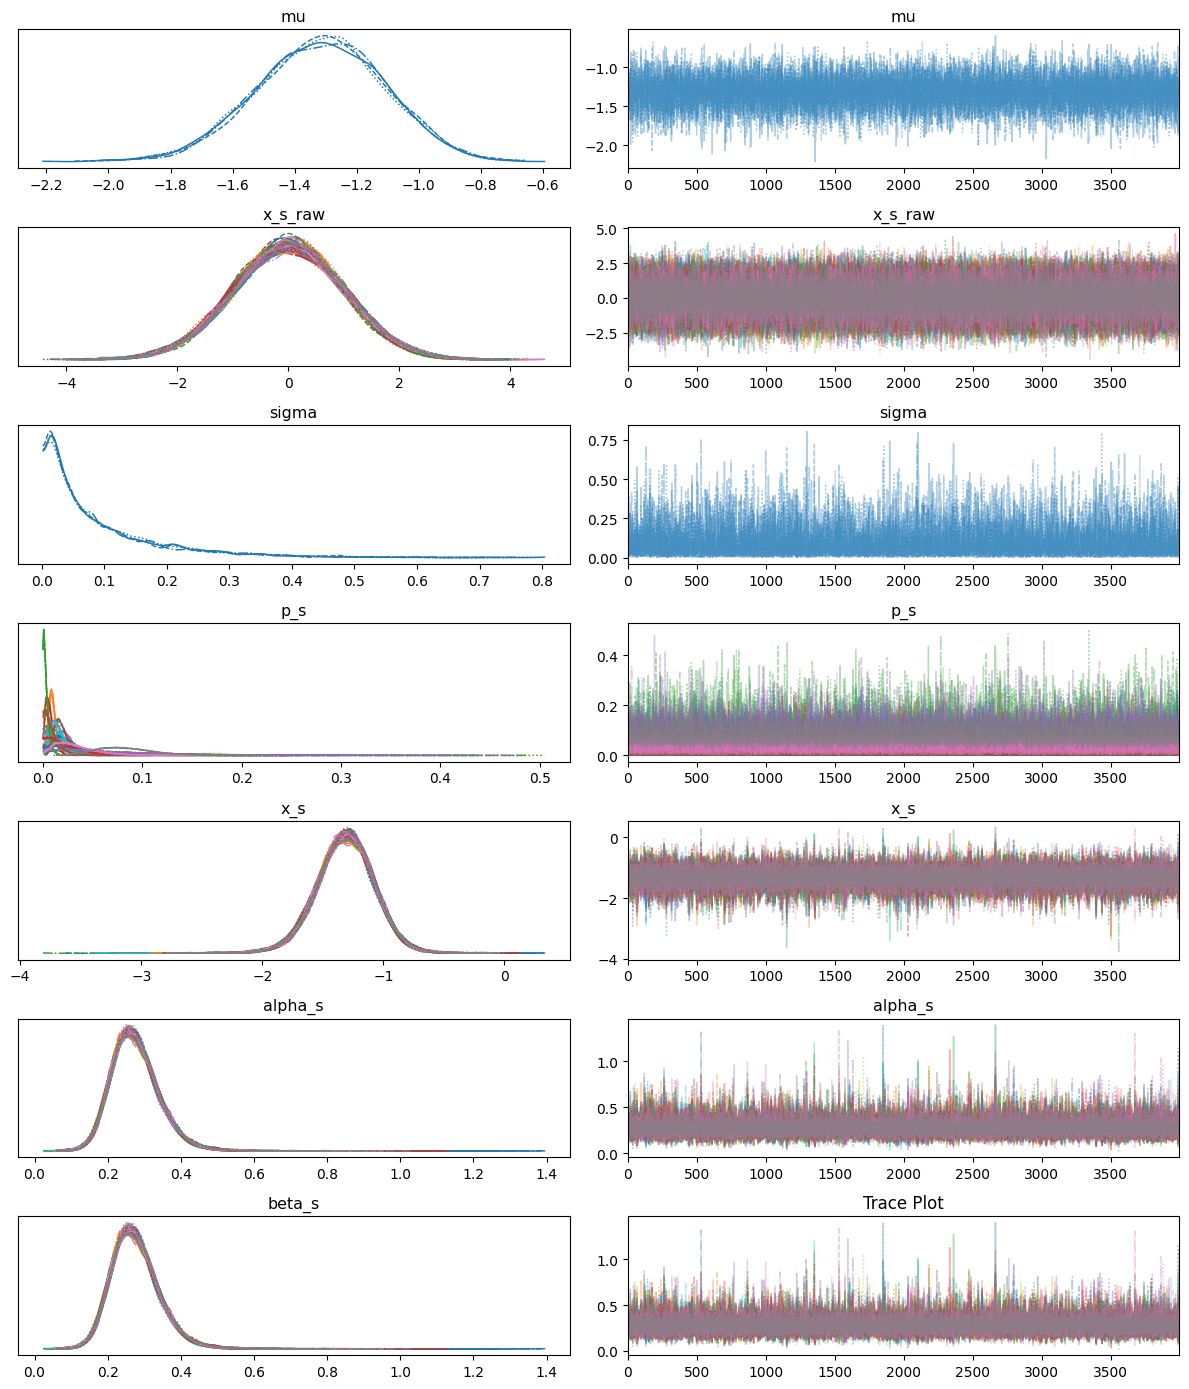

In [ ]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

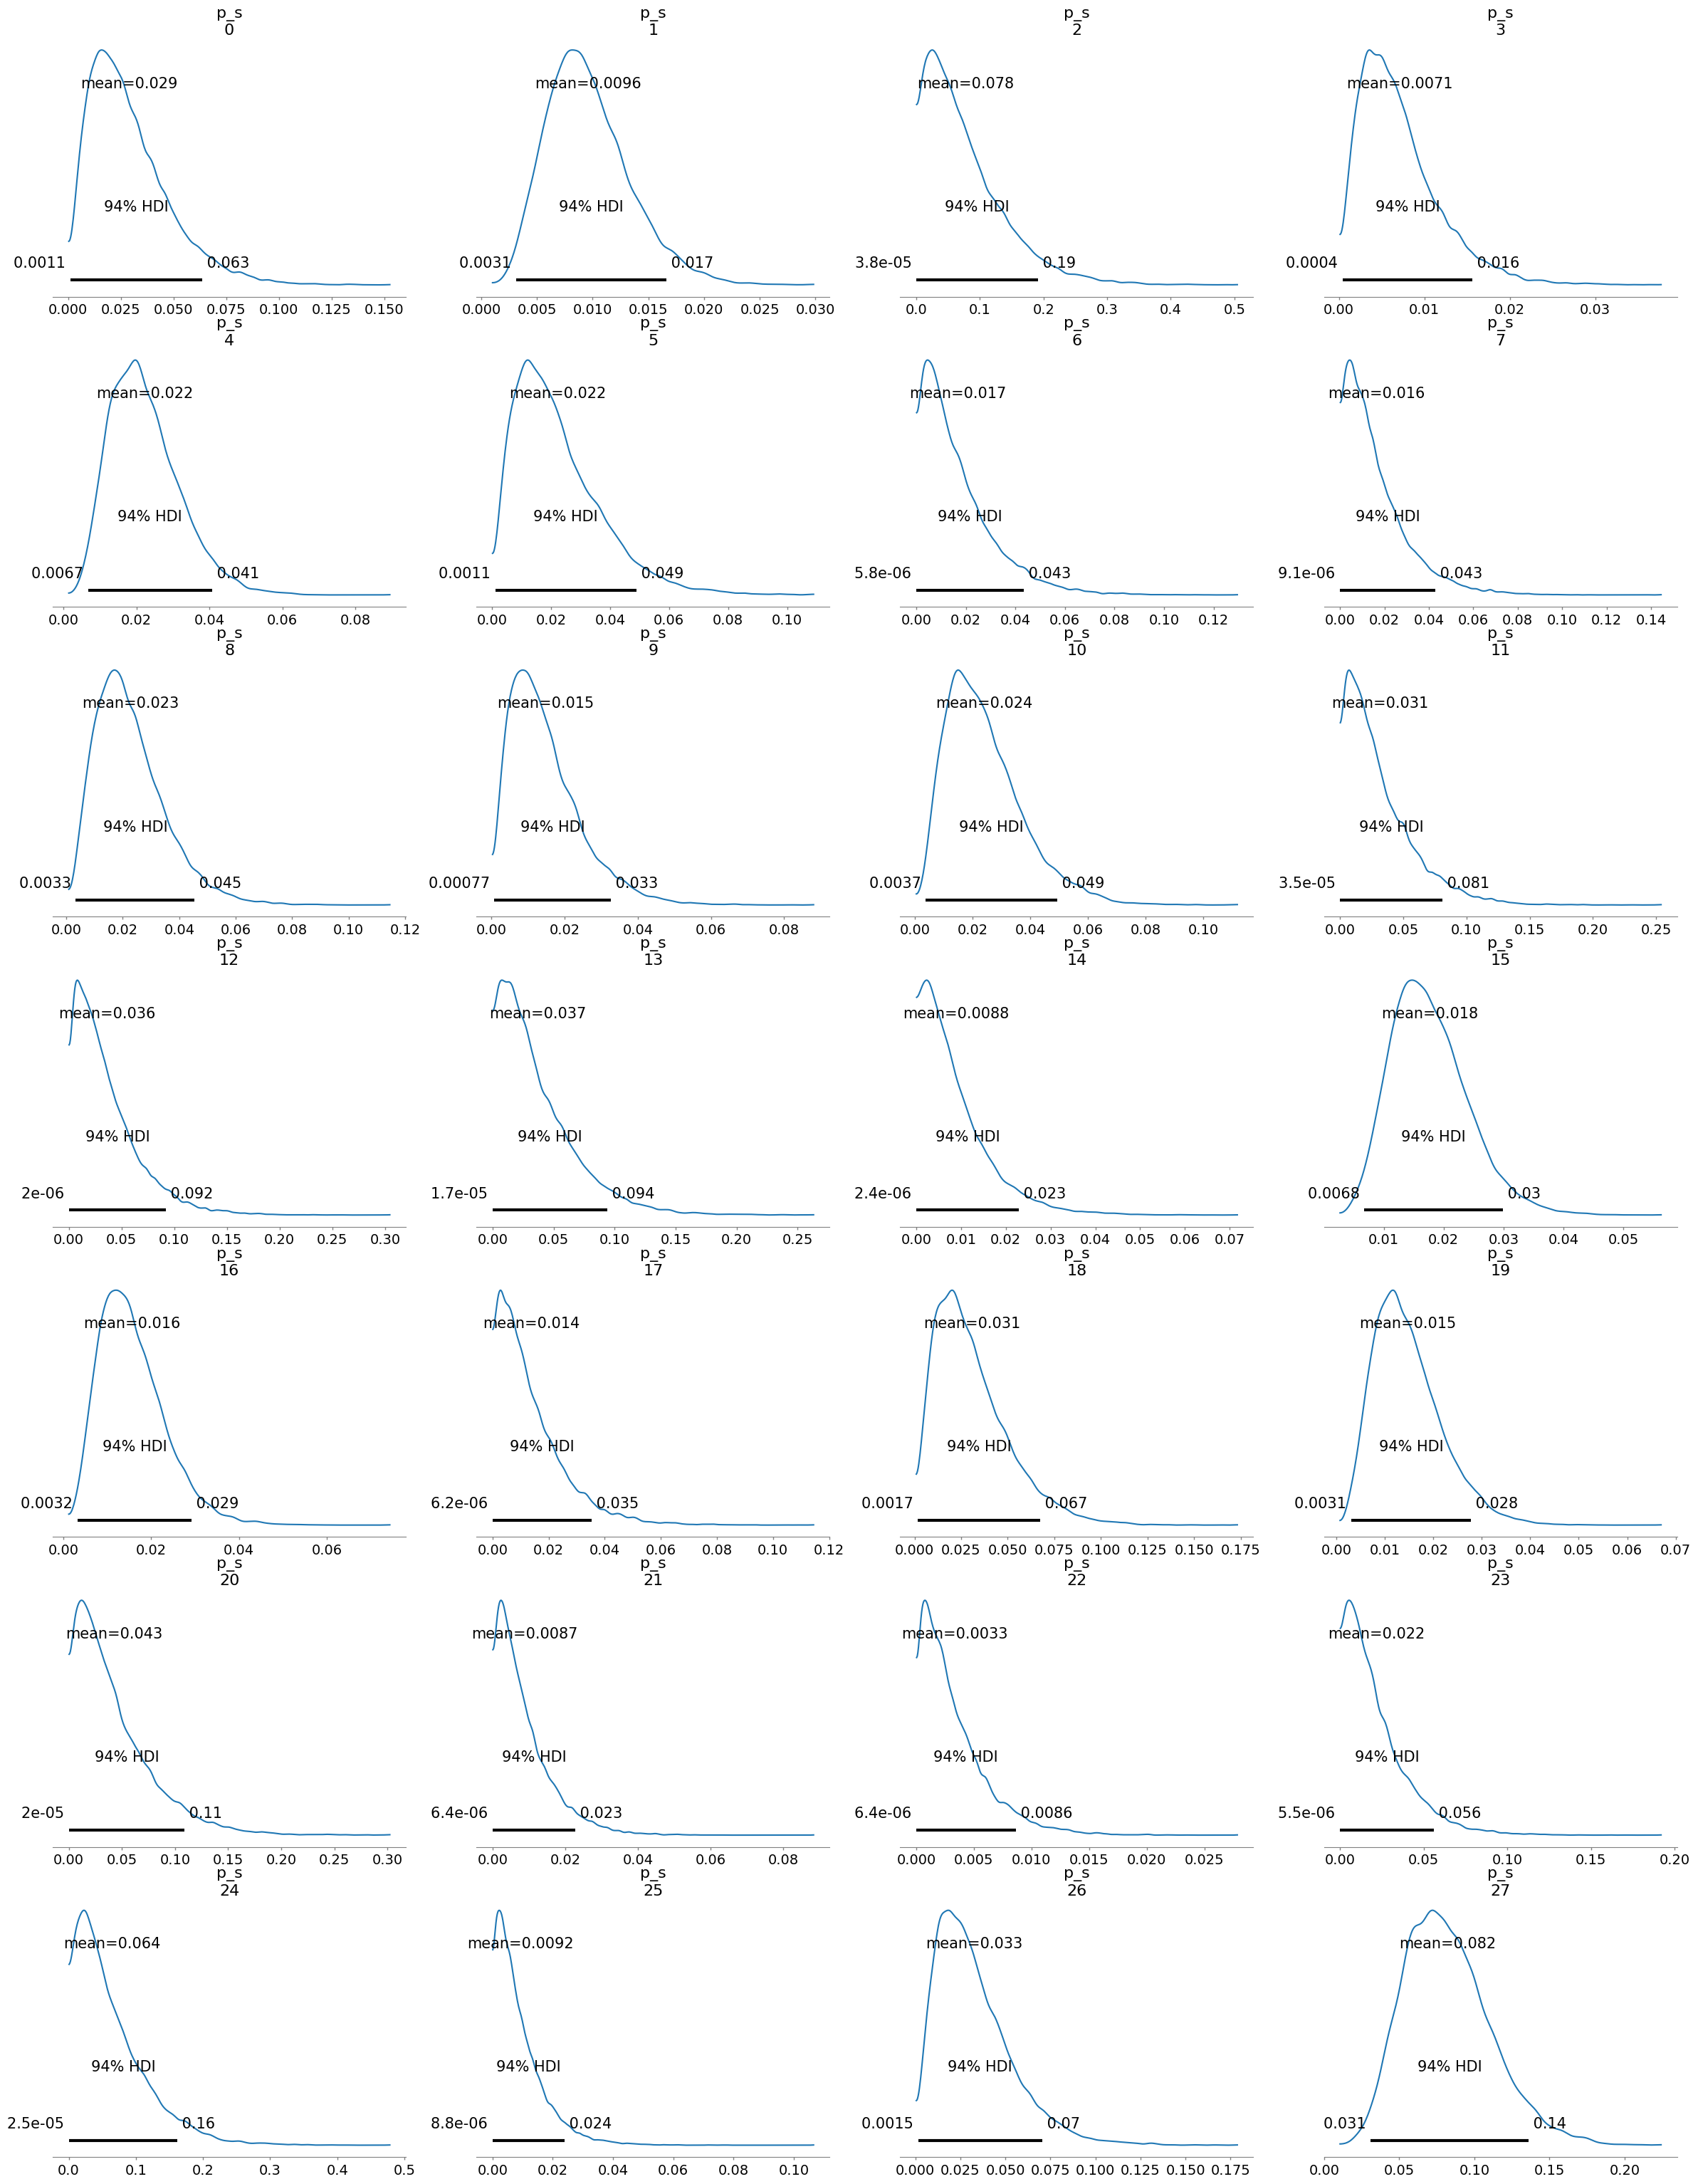

In [42]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()

### only-one layer

In [ ]:
# with pt.config.change_flags(exception_verbosity='high'):
#     with pm.Model() as model:
#         # alpha ~ Gamma(0.01, 0.01)
#         alpha = pm.Gamma('alpha', alpha=0.01, beta=0.01)
#         # beta ~ Gamma(0.01, 0.01)
#         beta = pm.Gamma('beta', alpha=0.01, beta=0.01)

#         # p_s ~ Beta(alpha, beta)
#         p_s = pm.Beta('p_s', alpha=alpha, beta=beta, shape=len(n_s))

#         # likelihood ~ Binomial(n_s, p_s)
#         y = pm.Binomial('y', n=n_s.values, p=p_s, observed=y_s.values)

#         trace = pm.sample(4000, tune=2000, target_accept=0.95, return_inferencedata=True, 
#                           random_seed=42, progressbar=True, max_treedepth=15)

# print("rows with r_hat > 1.01:", (az.rhat(trace) > 1.01).sum())
# print("rows with ess < 100:", (az.ess(trace) < 100).sum())
# print("rows with ess < 1000:", (az.ess(trace) < 1000).sum())
# az.to_netcdf(trace, 'traces/trace_simple.nc')